# Q5 — RAG (Retrieval-Augmented Generation)

**Grupo 2:** Francisco Cosme Monteiro Xavier, Heitor Andrade Moura, Isaac Augusto Santana Brito e João Pedro Monteiro da Silva Barros

- **Objetivo:** melhorar as respostas dando ao modelo trechos recuperados dos Diários.
- **Método:** chunk do corpus → embeddings (`multilingual-e5-small`) + índice FAISS → recupera top-k → gera com o contexto.
- **Avaliação:** SEM-RAG vs COM-RAG em **acerto factual** + **similaridade** (abertas) e **acurácia MCQ**.
- **Modelo / Dados:** Qwen3 (1.7B p/ teste → 4B oficial, 4-bit) · `gutoportelaa/dom-pi-corpus-2025`.
- **Escopo (honesto):** o índice **garante** o documento-fonte de cada pergunta + distratores. Portanto
  isto mede o RAG em cenário **open-book** ("se o doc certo está recuperável, o RAG ajuda?"), que é um
  limite superior; NÃO mede a recuperação em corpus aberto real (isso exigiria medir recall@k).

## Passo a passo
1. Carrega o Qwen3-4B em 4-bit.
2. Indexa o corpus (garante os documentos-fonte de cada pergunta) com embeddings e5 + FAISS.
3. Para cada uma das 30 perguntas, gera a resposta SEM RAG e COM RAG (contexto recuperado).
4. Compara as duas versões por acerto factual, similaridade e acurácia MCQ.
5. Salva results_q5.json.

### Setup — montar o Google Drive e entrar na pasta (persiste os resultados)

In [1]:
# Necessário p/ os results_qN.json caírem no Drive (não no /content efêmero). Fora do Colab, pule.
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/ufpi/topics-in-ai/final-project

Mounted at /content/drive
/content/drive/MyDrive/ufpi/topics-in-ai/final-project


### Instalação

In [2]:
!pip -q install -U transformers accelerate sentence-transformers faiss-cpu datasets bitsandbytes
!pip -q install -U pyarrow    # compat com datasets; se der "IpcReadOptions size changed", REINICIE a sessao e rode de novo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.3 MB/s eta 0:00:00


### Modelo gerador (seletor de modo)

In [3]:
import torch, statistics as st
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODE = "oficial"        # "smoke" (1.7B, 300 docs) ou "oficial" (4B, 1500 docs)
CFG = {"smoke":   {"model": "Qwen/Qwen3-1.7B", "n_docs": 300},
       "oficial": {"model": "Qwen/Qwen3-4B",   "n_docs": 600}}[MODE]   # distratores (docs-fonte são garantidos à parte)
MODEL_ID, N_DOCS = CFG["model"], CFG["n_docs"]
print(f"MODE={MODE} | modelo={MODEL_ID} | docs indexados={N_DOCS}")

tok = AutoTokenizer.from_pretrained(MODEL_ID)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, quantization_config=bnb, device_map="auto").eval()

def gerar(pergunta, contexto=None, max_new=96):   # respostas do benchmark são curtas; 96 basta e acelera
    user = pergunta if not contexto else (
        f"Use SOMENTE o contexto para responder. Se não estiver no contexto, diga que não sabe.\n"
        f"Contexto:\n{contexto}\n\nPergunta: {pergunta}")
    enc = tok.apply_chat_template([{"role": "user", "content": user}], tokenize=True,
            add_generation_prompt=True, enable_thinking=False, return_tensors="pt", return_dict=True).to(model.device)
    out = model.generate(**enc, max_new_tokens=max_new, do_sample=False, pad_token_id=tok.pad_token_id)
    return tok.decode(out[0, enc["input_ids"].shape[1]:], skip_special_tokens=True).strip()

MODE=oficial | modelo=Qwen/Qwen3-4B | docs indexados=600


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/32.8k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

### Benchmark ABERTO (30 perguntas) + corpus DOM-PI -> chunks

In [4]:
# O benchmark cobre VÁRIOS municípios; garantimos que os documentos-fonte de cada pergunta entrem
# no índice (fonte = prefixo de 8 chars do `id` do corpus) + distratores quality-A de todo o estado.
from datasets import load_dataset
abertas = [
    {"q": "Qual o valor do crédito suplementar aberto pela Portaria nº 790, de 12/12/2025, de Teresina?", "ref": "R$ 1.103.110,00 (um milhão, cento e três mil, cento e dez reais)", "fonte": "1f395839"},
    {"q": "De qual município é a Portaria nº 790/2025 que abre crédito suplementar de R$ 1.103.110,00?", "ref": "Teresina", "fonte": "1f395839"},
    {"q": "Qual o valor do crédito suplementar da Portaria nº 143, de 19 de maio de 2025 (Teresina)?", "ref": "R$ 300.000,00 (trezentos mil reais)", "fonte": "7262a76a"},
    {"q": "Qual o valor do crédito suplementar aberto pela Portaria nº 242, de 03 de julho de 2025?", "ref": "R$ 30.000,00 (trinta mil reais)", "fonte": "9d0162c9"},
    {"q": "Qual autoridade assina as portarias de crédito suplementar do Município de Teresina?", "ref": "O Secretário Municipal de Planejamento e Coordenação", "fonte": "1f395839"},
    {"q": "Qual o valor mensal do Contrato de Locação nº 004/2025 da Prefeitura de Várzea Branca?", "ref": "R$ 500,00 (quinhentos reais) por mês", "fonte": "084f5473"},
    {"q": "Qual a vigência do Contrato de Locação nº 004/2025 de Várzea Branca?", "ref": "12 (doze) meses, podendo ser prorrogado", "fonte": "084f5473"},
    {"q": "Qual empresa venceu a Concorrência Eletrônica nº 001/2025 do município de Cocal?", "ref": "F Santos Construtora e Serviços LTDA (CNPJ 09.228.043/0001-01)", "fonte": "5a81d487"},
    {"q": "Qual o valor do contrato da Concorrência Eletrônica nº 001/2025 de Cocal?", "ref": "R$ 3.617.082,24", "fonte": "5a81d487"},
    {"q": "Qual o objeto da Concorrência Eletrônica nº 001/2025 do município de Cocal?", "ref": "Pavimentação de vias públicas em paralelepípedo", "fonte": "5a81d487"},
    {"q": "Qual empresa foi adjudicada para a recuperação de estradas vicinais em Barras?", "ref": "Liderança Construtora LTDA (CNPJ 29.485.438/0001-99)", "fonte": "b4742139"},
    {"q": "Por qual valor foi adjudicada a recuperação de estradas vicinais em Barras?", "ref": "R$ 827.500,00", "fonte": "b4742139"},
    {"q": "O que regulamenta o decreto do município de São Raimundo Nonato de 24/10/2025?", "ref": "Institui/regulamenta o IPTU Premiado", "fonte": "2f306135"},
    {"q": "Qual cargo é objeto de exoneração na Portaria nº 104/2025 de Pajeú do Piauí?", "ref": "Chefe do Setor de Transporte e Máquinas", "fonte": "179c6341"},
    {"q": "Que fundo municipal é criado pela norma do município de Jaicós (art. 16)?", "ref": "Fundo Municipal de Direitos do Idoso", "fonte": "286a2431"},
    {"q": "Qual o objeto do contrato por inexigibilidade nº 005/2025 da Câmara Municipal de Gilbués?", "ref": "Consultoria e assessoria especializada em gestão de folha de pagamento e assessoria fiscal e previdenciária", "fonte": "c2bc1f8f"},
    {"q": "Quem foi nomeada Assessor de Gabinete pela Portaria nº 142/2025 (Tamboril do Piauí)?", "ref": "Esther de Aguiar Luz", "fonte": "e4c03c07"},
    {"q": "Para qual cargo comissionado foi nomeada Esther de Aguiar Luz na Portaria nº 142/2025?", "ref": "Assessor de Gabinete (símbolo DAS CC-4)", "fonte": "e4c03c07"},
    {"q": "Qual o tipo da licitação (Pregão Eletrônico nº 048/2025) de Redenção do Gurguéia?", "ref": "Menor preço por lote", "fonte": "2eed7f6e"},
    {"q": "Qual a modalidade de licitação da Ata de Registro de Preços nº 0021/2025 de Lagoa de São Francisco?", "ref": "Pregão", "fonte": "46e01b05"},
    {"q": "Quais profissionais o Edital de Chamada Pública Simplificada nº 001/2025 (Ribeiro Gonçalves) busca contratar?", "ref": "Operador de pá escavadeira, operador de retroescavadeira e operador de motoniveladora", "fonte": "1bb9a766"},
    {"q": "Qual o cargo da Chamada Pública Simplificada nº 002/2025 de Ribeira do Piauí?", "ref": "Cuidador Escolar", "fonte": "365e5687"},
    {"q": "Qual a carga horária do cargo da Chamada Pública nº 002/2025 de Ribeira do Piauí?", "ref": "40 horas", "fonte": "365e5687"},
    {"q": "Qual o objeto da Inexigibilidade de Licitação nº 019/2025 de Parnaguá?", "ref": "Assessoria técnica em saúde para fortalecimento da gestão municipal do SUS", "fonte": "a7e346eb"},
    {"q": "Por que foi emitido o Termo de Retificação ao Aditivo nº 011/2025 de Sebastião Leal?", "ref": "Para corrigir erro de digitação na cláusula de vigência do aditivo", "fonte": "39cac340"},
    {"q": "Qual decreto é corrigido pela errata publicada por São Lourenço do Piauí?", "ref": "Decreto nº 028/2025", "fonte": "2cee3d0a"},
    {"q": "A que exercício se refere o Orçamento-Programa da Câmara Municipal de Boqueirão do Piauí?", "ref": "Exercício de 2026", "fonte": "1aac1fb8"},
    {"q": "Qual a lei federal de licitações e contratos citada como fundamento nos atos do DOM-PI?", "ref": "Lei nº 14.133/2021", "fonte": "2f306135"},
    {"q": "Classifique o tipo de ato: 'Abre Crédito Suplementar no Orçamento-Programa vigente, no valor de R$ 30.000,00'.", "ref": "Portaria", "fonte": "9d0162c9"},
    {"q": "O Diário Oficial dos Municípios (DOM) usado neste corpus é de qual estado?", "ref": "Piauí", "fonte": "1f395839"},
]
FONTES = {it["fonte"] for it in abertas if it.get("fonte")}
corpus = load_dataset("gutoportelaa/dom-pi-corpus-2025", "curated", split="train")
fonte_ds = corpus.filter(lambda r: r["id"][:8] in FONTES)                                 # docs que respondem o benchmark
dist_ds = corpus.filter(lambda r: r["quality_tier"] == "A").shuffle(seed=42).select(range(N_DOCS))  # distratores
textos = list(fonte_ds["texto"]) + list(dist_ds["texto"])
def chunk_texto(t, tam=800, ov=100):
    return [t[i:i+tam].strip() for i in range(0, len(t), tam-ov) if len(t[i:i+tam].strip()) > 50]
chunks = []
for t in textos:
    chunks += chunk_texto(t)
print(f"docs-fonte: {len(fonte_ds)} | distratores: {len(dist_ds)} | chunks: {len(chunks)}")

README.md:   0%|          | 0.00/6.07k [00:00<?, ?B/s]

curated/curated-00000-of-00002.parquet:   0%|          | 0.00/118M [00:00<?, ?B/s]

curated/curated-00001-of-00002.parquet:   0%|          | 0.00/50.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/70826 [00:00<?, ? examples/s]

Filter:   0%|          | 0/70826 [00:00<?, ? examples/s]

Filter:   0%|          | 0/70826 [00:00<?, ? examples/s]

docs-fonte: 19 | distratores: 600 | chunks: 6712


### Embeddings (multilingual-e5-small) + índice FAISS

In [5]:
from sentence_transformers import SentenceTransformer
import faiss
emb = SentenceTransformer("intfloat/multilingual-e5-small")   # leve; resultado executado usa este
vec = emb.encode(chunks, normalize_embeddings=True, show_progress_bar=True, batch_size=64).astype("float32")
index = faiss.IndexFlatIP(vec.shape[1]); index.add(vec)
def recuperar(q, k=4):
    qv = emb.encode([q], normalize_embeddings=True).astype("float32")
    _, I = index.search(qv, k)
    return [chunks[i] for i in I[0]]
def rag(q, k=4):
    return gerar(q, "\n---\n".join(recuperar(q, k)))

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/105 [00:00<?, ?it/s]

### Avaliação nas 30 abertas — similaridade (satura) + ACERTO FACTUAL (sem/com RAG)

In [6]:
import re, unicodedata
from sentence_transformers import util
def sim(a, b):
    va = emb.encode(a, normalize_embeddings=True); vb = emb.encode(b, normalize_embeddings=True)
    return float(util.cos_sim(va, vb))
def _norm(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode().lower()
    s = re.sub(r"\([^)]*\)", " ", s)               # ignora parênteses na referência
    return re.sub(r"[^a-z0-9]+", " ", s).strip()
def factual(resp, ref):
    nr = _norm(ref)
    return int(bool(nr) and nr in _norm(resp))     # a referência aparece (normalizada) na resposta?
# A similaridade SATURA (resposta errada no mesmo tema pontua alto, ex.: cidade errada ~0,80). O
# ACERTO FACTUAL é a métrica honesta nas abertas; a acurácia MCQ (Cell 6) é a principal.
rows = []
for it in abertas:
    rs, rc = gerar(it["q"]), rag(it["q"])          # resposta sem-RAG e com-RAG
    rows.append({"sem": sim(rs, it["ref"]), "com": sim(rc, it["ref"]),
                 "fsem": factual(rs, it["ref"]), "fcom": factual(rc, it["ref"])})
sim_sem = round(st.mean(r["sem"] for r in rows), 3)
sim_com = round(st.mean(r["com"] for r in rows), 3)
fac_sem = round(st.mean(r["fsem"] for r in rows), 3)
fac_com = round(st.mean(r["fcom"] for r in rows), 3)
print(f"Similaridade   SEM: {sim_sem} | COM: {sim_com}   (satura — não confiar)")
print(f"Acerto factual SEM: {fac_sem} | COM: {fac_com}   (ganho real do RAG nas abertas)")

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Similaridade   SEM: 0.831 | COM: 0.856   (satura — não confiar)
Acerto factual SEM: 0 | COM: 0.433   (ganho real do RAG nas abertas)


### Benchmark MCQ (Teresina) — Acurácia SEM-RAG vs COM-RAG (log-prob)

In [7]:
mcq = [
 {"q":"Valor do crédito suplementar da Portaria nº 790/2025 (Teresina)?",
  "options":["R$ 1.103.110,00","R$ 300.000,00","R$ 30.000,00","R$ 50.000,00"],"answer":0},
 {"q":"Valor do crédito suplementar da Portaria nº 143/2025 (Teresina)?",
  "options":["R$ 30.000,00","R$ 300.000,00","R$ 1.103.110,00","R$ 100.000,00"],"answer":1},
 {"q":"Valor do crédito suplementar da Portaria nº 242/2025 (Teresina)?",
  "options":["R$ 300.000,00","R$ 1.000.000,00","R$ 30.000,00","R$ 3.000,00"],"answer":2},
 {"q":"Quem assina as portarias de crédito suplementar de Teresina?",
  "options":["O Prefeito Municipal","O Secretário Municipal de Planejamento e Coordenação","O Secretário de Fazenda","A Câmara Municipal"],"answer":1},
 {"q":"Qual lei de 2025 alterou a abertura de créditos em Teresina?",
  "options":["Lei nº 6.125/2024","Lei nº 4.320/1964","Lei nº 6.188/2025","Lei nº 6.163/2024"],"answer":2},
 {"q":"Qual lei de 31/07/2024 dá suporte às portarias de crédito de Teresina?",
  "options":["Lei nº 6.125/2024","Lei nº 6.188/2025","Lei nº 14.133/2021","Lei nº 4.320/1964"],"answer":0},
 {"q":"A que peça orçamentária as portarias de crédito de Teresina se referem?",
  "options":["Plano Plurianual","Orçamento-Programa vigente","LDO","Balanço Geral"],"answer":1},
 {"q":"O Diário Oficial dos Municípios usado é de qual estado?",
  "options":["Maranhão","Ceará","Piauí","Bahia"],"answer":2},
]
@torch.no_grad()
def score_mcq(pergunta, opcoes, contexto=None):
    user = (pergunta if not contexto else f"Contexto:\n{contexto}\n\n{pergunta}") + \
           "\nResponda apenas com a alternativa correta."
    base = tok.apply_chat_template([{"role":"user","content":user}], tokenize=False,
                                   add_generation_prompt=True, enable_thinking=False)
    bid = tok(base, return_tensors="pt").input_ids.to(model.device)
    best, bs = 0, -1e9
    for i, op in enumerate(opcoes):
        oid = tok(" "+op, return_tensors="pt", add_special_tokens=False).input_ids.to(model.device)
        full = torch.cat([bid, oid], dim=1); lab = full.clone(); lab[:, :bid.shape[1]] = -100
        s = -model(full, labels=lab).loss.item()
        if s > bs: best, bs = i, s
    return best
acc_sem = sum(score_mcq(it["q"], it["options"]) == it["answer"] for it in mcq) / len(mcq)
acc_com = sum(score_mcq(it["q"], it["options"], "\n---\n".join(recuperar(it["q"], 4))) == it["answer"] for it in mcq) / len(mcq)
print(f"Acuracia MCQ  SEM-RAG: {acc_sem:.3f}  | COM-RAG: {acc_com:.3f}  | aleatorio = 0.25")

Acuracia MCQ  SEM-RAG: 0.250  | COM-RAG: 0.875  | aleatorio = 0.25


### Salvar resultados

In [8]:
import json
res = {"questao": "Q5-RAG", "modo": MODE, "modelo": MODEL_ID,
       "docs": len(fonte_ds) + len(dist_ds), "n_abertas": len(abertas), "n_mcq": len(mcq),
       "sim_sem": sim_sem, "sim_com": sim_com,
       "fac_sem": fac_sem, "fac_com": fac_com,
       "mcq_sem": round(acc_sem, 3), "mcq_com": round(acc_com, 3)}
json.dump(res, open("results_q5.json", "w"), ensure_ascii=False, indent=2)
print("results_q5.json:", res)

results_q5.json: {'questao': 'Q5-RAG', 'modo': 'oficial', 'modelo': 'Qwen/Qwen3-4B', 'docs': 619, 'n_abertas': 30, 'n_mcq': 8, 'sim_sem': 0.831, 'sim_com': 0.856, 'fac_sem': 0, 'fac_com': 0.433, 'mcq_sem': 0.25, 'mcq_com': 0.875}


## Conclusão
- O RAG melhora as respostas factuais (o modelo cru não conhece os fatos locais).
- **Cuidado com a similaridade — ela satura:** uma resposta errada no mesmo tema pontua alto. Ex.:
  à pergunta sobre a Portaria 790, o modelo respondeu *"São João del Rei/MG"* (errado) e mesmo assim
  a similaridade deu **0,80**. Por isso medimos também o **acerto factual** (a referência aparece na
  resposta?), que pega o erro (= 0), e a **acurácia MCQ** como métrica principal de fato.
- Referência (demo 1.7B): similaridade 0,835 → 0,884; **MCQ 25% → 87,5%**.
- **Escopo:** benchmark de **30 perguntas** cobrindo vários municípios; o índice garante os
  documentos-fonte de cada pergunta + distratores quality-A de todo o estado, então o RAG é
  avaliado de forma justa. O ganho do RAG depende de o documento certo estar recuperável.

### Gráfico do resultado — RAG sem vs com

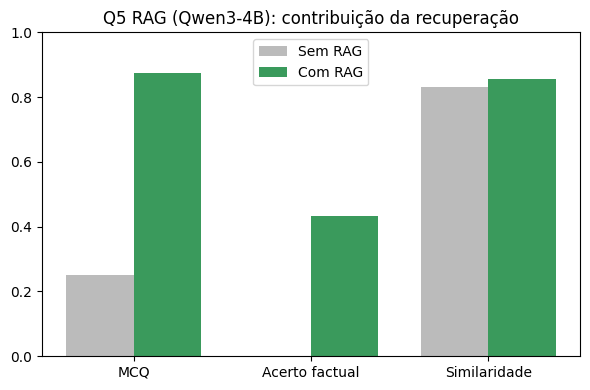

In [9]:
import matplotlib.pyplot as plt, numpy as np
cats = ["MCQ", "Acerto factual", "Similaridade"]
sem = [acc_sem, fac_sem, sim_sem]; com = [acc_com, fac_com, sim_com]
x = np.arange(3); w = 0.38
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - w/2, sem, w, label="Sem RAG", color="#bbb")
ax.bar(x + w/2, com, w, label="Com RAG", color="#3a9a5c")
ax.set_ylim(0, 1); ax.set_xticks(x); ax.set_xticklabels(cats); ax.legend()
ax.set_title("Q5 RAG (Qwen3-4B): contribuição da recuperação")
plt.tight_layout(); plt.show()